# Task 1 — ResNet-152


## Setup


In [15]:
import csv
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from torch.utils.data import DataLoader, random_split
from torchvision import datasets
from torchvision.models import resnet152, ResNet152_Weights


SEED = 42
BATCH_SIZE = 32
EPOCHS = 3
LEARNING_RATE = 0.001

RESULTS_DIR = Path("task1/results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


## Dataset and DataLoaders


In [16]:
weights = ResNet152_Weights.DEFAULT
transform = weights.transforms()

full_train_dataset = datasets.CIFAR10(
    root="/kaggle/input/datasets/sohauvv/cifar10-local",
    train=True,
    download=False,
    transform=transform,
)

test_dataset = datasets.CIFAR10(
    root="/kaggle/input/datasets/sohauvv/cifar10-local",
    train=False,
    download=False,
    transform=transform,
)

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [45000, 5000],
    generator=torch.Generator().manual_seed(SEED),
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
    generator=torch.Generator().manual_seed(SEED),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)

print("Train images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))

print()

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train images: 45000
Validation images: 5000
Test images: 10000

Train batches: 1407
Validation batches: 157
Test batches: 313


## Training and Evaluation Functions

In [17]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

## 1.1 Transfer Learning Baseline

In [18]:
baseline_model = resnet152(weights=weights)

baseline_model.fc = nn.Linear(
    baseline_model.fc.in_features,
    10,
)


# Freeze the pretrained backbone
for param in baseline_model.parameters():
    param.requires_grad = False


# Train only the new classification head
for param in baseline_model.fc.parameters():
    param.requires_grad = True


baseline_model = baseline_model.to(device)


trainable_params = sum(
    param.numel()
    for param in baseline_model.parameters()
    if param.requires_grad
)

total_params = sum(
    param.numel()
    for param in baseline_model.parameters()
)


print(f"Trainable parameters: {trainable_params:,}")
print(f"Total parameters: {total_params:,}")
print("Classifier:", baseline_model.fc)

Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /root/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth


100%|██████████| 230M/230M [00:01<00:00, 226MB/s]  


Trainable parameters: 20,490
Total parameters: 58,164,298
Classifier: Linear(in_features=2048, out_features=10, bias=True)


### Training

In [19]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    baseline_model.fc.parameters(),
    lr=LEARNING_RATE,
)


baseline_history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}


for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(
        baseline_model,
        train_loader,
        criterion,
        optimizer,
        device,
    )

    val_loss, val_acc = evaluate(
        baseline_model,
        val_loader,
        criterion,
        device,
    )

    baseline_history["train_loss"].append(train_loss)
    baseline_history["train_acc"].append(train_acc)
    baseline_history["val_loss"].append(val_loss)
    baseline_history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch 1/3 | Train Loss: 0.7041 | Train Acc: 0.7757 | Val Loss: 0.5211 | Val Acc: 0.8270
Epoch 2/3 | Train Loss: 0.5192 | Train Acc: 0.8242 | Val Loss: 0.5049 | Val Acc: 0.8320
Epoch 3/3 | Train Loss: 0.4808 | Train Acc: 0.8354 | Val Loss: 0.4712 | Val Acc: 0.8432


### Test Evaluation

In [20]:
baseline_test_loss, baseline_test_acc = evaluate(
    baseline_model,
    test_loader,
    criterion,
    device,
)


print(f"Test Loss: {baseline_test_loss:.4f}")
print(f"Test Accuracy: {baseline_test_acc:.4f}")

Test Loss: 0.4778
Test Accuracy: 0.8390


### Results

In [21]:
# Save epoch-by-epoch history

history_path = RESULTS_DIR / "baseline_history.csv"

with open(history_path, "w", newline="") as file:
    writer = csv.writer(file)

    writer.writerow([
        "epoch",
        "train_loss",
        "train_acc",
        "val_loss",
        "val_acc",
    ])

    for epoch in range(EPOCHS):
        writer.writerow([
            epoch + 1,
            baseline_history["train_loss"][epoch],
            baseline_history["train_acc"][epoch],
            baseline_history["val_loss"][epoch],
            baseline_history["val_acc"][epoch],
        ])


# Save final metrics

summary_path = RESULTS_DIR / "baseline_summary.csv"

with open(summary_path, "w", newline="") as file:
    writer = csv.writer(file)

    writer.writerow([
        "final_train_loss",
        "final_train_acc",
        "final_val_loss",
        "final_val_acc",
        "test_loss",
        "test_acc",
    ])

    writer.writerow([
        baseline_history["train_loss"][-1],
        baseline_history["train_acc"][-1],
        baseline_history["val_loss"][-1],
        baseline_history["val_acc"][-1],
        baseline_test_loss,
        baseline_test_acc,
    ])


print("History saved to:", history_path)
print("Summary saved to:", summary_path)

History saved to: task1/results/baseline_history.csv
Summary saved to: task1/results/baseline_summary.csv


### Training Curves

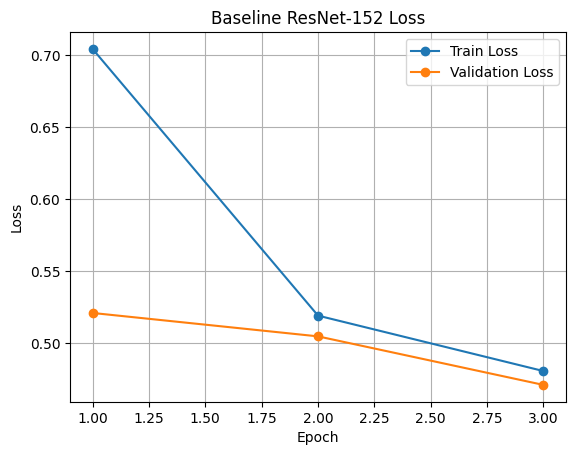

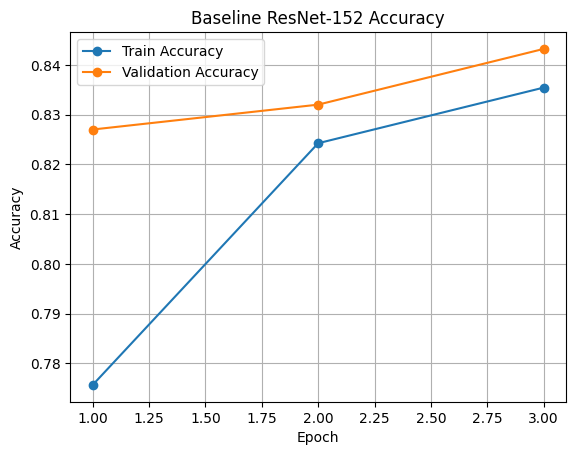

Loss plot saved to: task1/results/baseline_loss.png
Accuracy plot saved to: task1/results/baseline_accuracy.png


In [22]:
epochs_range = range(1, EPOCHS + 1)


# Loss

plt.figure()

plt.plot(
    epochs_range,
    baseline_history["train_loss"],
    marker="o",
    label="Train Loss",
)

plt.plot(
    epochs_range,
    baseline_history["val_loss"],
    marker="o",
    label="Validation Loss",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline ResNet-152 Loss")
plt.legend()
plt.grid()

loss_plot_path = RESULTS_DIR / "baseline_loss.png"

plt.savefig(
    loss_plot_path,
    bbox_inches="tight",
)

plt.show()


# Accuracy

plt.figure()

plt.plot(
    epochs_range,
    baseline_history["train_acc"],
    marker="o",
    label="Train Accuracy",
)

plt.plot(
    epochs_range,
    baseline_history["val_acc"],
    marker="o",
    label="Validation Accuracy",
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline ResNet-152 Accuracy")
plt.legend()
plt.grid()

accuracy_plot_path = RESULTS_DIR / "baseline_accuracy.png"

plt.savefig(
    accuracy_plot_path,
    bbox_inches="tight",
)

plt.show()


print("Loss plot saved to:", loss_plot_path)
print("Accuracy plot saved to:", accuracy_plot_path)

## 1.2 Residual Connections in Practice

### Modified Residual Blocks


In [23]:
import types


def forward_without_skip(self, x):
    out = self.conv1(x)
    out = self.bn1(out)
    out = self.relu(out)

    out = self.conv2(out)
    out = self.bn2(out)
    out = self.relu(out)

    out = self.conv3(out)
    out = self.bn3(out)

    # Residual connection removed
    out = self.relu(out)

    return out

### Model Setup

In [24]:
no_skip_model = resnet152(weights=weights)

no_skip_model.fc = nn.Linear(
    no_skip_model.fc.in_features,
    10,
)


# Select one residual block from each stage
blocks_without_skip = [
    no_skip_model.layer1[1],
    no_skip_model.layer2[1],
    no_skip_model.layer3[1],
    no_skip_model.layer4[1],
]


# Replace their forward methods
for block in blocks_without_skip:
    block.forward = types.MethodType(
        forward_without_skip,
        block,
    )


# Freeze pretrained backbone
for param in no_skip_model.parameters():
    param.requires_grad = False


# Train only classifier
for param in no_skip_model.fc.parameters():
    param.requires_grad = True


no_skip_model = no_skip_model.to(device)


print("Skip connections disabled in:")
print("layer1[1]")
print("layer2[1]")
print("layer3[1]")
print("layer4[1]")

Skip connections disabled in:
layer1[1]
layer2[1]
layer3[1]
layer4[1]


### Training

In [25]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    no_skip_model.fc.parameters(),
    lr=LEARNING_RATE,
)


no_skip_history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}


for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(
        no_skip_model,
        train_loader,
        criterion,
        optimizer,
        device,
    )

    val_loss, val_acc = evaluate(
        no_skip_model,
        val_loader,
        criterion,
        device,
    )

    no_skip_history["train_loss"].append(train_loss)
    no_skip_history["train_acc"].append(train_acc)
    no_skip_history["val_loss"].append(val_loss)
    no_skip_history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch 1/3 | Train Loss: 2.3015 | Train Acc: 0.1063 | Val Loss: 2.5446 | Val Acc: 0.1138
Epoch 2/3 | Train Loss: 2.2989 | Train Acc: 0.1156 | Val Loss: 2.4674 | Val Acc: 0.1232
Epoch 3/3 | Train Loss: 2.2975 | Train Acc: 0.1178 | Val Loss: 2.4069 | Val Acc: 0.1154


### Test Evaluation

In [26]:
no_skip_test_loss, no_skip_test_acc = evaluate(
    no_skip_model,
    test_loader,
    criterion,
    device,
)

print(f"Test Loss: {no_skip_test_loss:.4f}")
print(f"Test Accuracy: {no_skip_test_acc:.4f}")

Test Loss: 2.4321
Test Accuracy: 0.1207


### Results

In [28]:
# Save no-skip history
no_skip_history_path = RESULTS_DIR / "no_skip_history.csv"

with open(no_skip_history_path, "w", newline="") as file:
    writer = csv.writer(file)

    writer.writerow([
        "epoch",
        "train_loss",
        "train_acc",
        "val_loss",
        "val_acc",
    ])

    for epoch in range(EPOCHS):
        writer.writerow([
            epoch + 1,
            no_skip_history["train_loss"][epoch],
            no_skip_history["train_acc"][epoch],
            no_skip_history["val_loss"][epoch],
            no_skip_history["val_acc"][epoch],
        ])


# Save no-skip summary
no_skip_summary_path = RESULTS_DIR / "no_skip_summary.csv"

with open(no_skip_summary_path, "w", newline="") as file:
    writer = csv.writer(file)

    writer.writerow([
        "final_train_loss",
        "final_train_acc",
        "final_val_loss",
        "final_val_acc",
        "test_loss",
        "test_acc",
    ])

    writer.writerow([
        no_skip_history["train_loss"][-1],
        no_skip_history["train_acc"][-1],
        no_skip_history["val_loss"][-1],
        no_skip_history["val_acc"][-1],
        no_skip_test_loss,
        no_skip_test_acc,
    ])


print("No-skip history saved to:", no_skip_history_path)
print("No-skip summary saved to:", no_skip_summary_path)

No-skip history saved to: task1/results/no_skip_history.csv
No-skip summary saved to: task1/results/no_skip_summary.csv


### Baseline Comparison

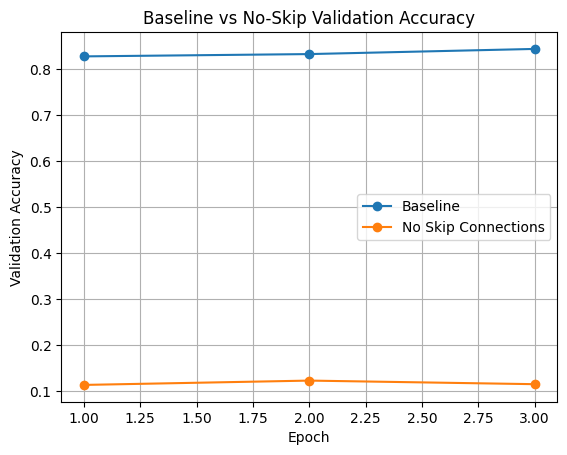

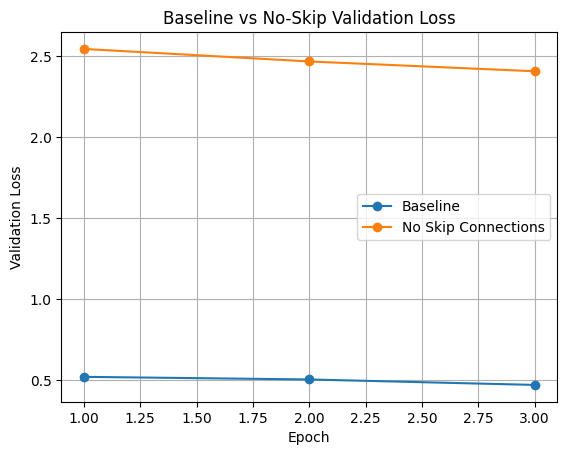

Comparison accuracy plot saved to: task1/results/baseline_vs_no_skip_accuracy.png
Comparison loss plot saved to: task1/results/baseline_vs_no_skip_loss.png


In [29]:
epochs_range = range(1, EPOCHS + 1)


# Validation accuracy comparison
plt.figure()

plt.plot(
    epochs_range,
    baseline_history["val_acc"],
    marker="o",
    label="Baseline",
)

plt.plot(
    epochs_range,
    no_skip_history["val_acc"],
    marker="o",
    label="No Skip Connections",
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Baseline vs No-Skip Validation Accuracy")
plt.legend()
plt.grid()

comparison_acc_path = RESULTS_DIR / "baseline_vs_no_skip_accuracy.png"

plt.savefig(
    comparison_acc_path,
    bbox_inches="tight",
)

plt.show()


# Validation loss comparison
plt.figure()

plt.plot(
    epochs_range,
    baseline_history["val_loss"],
    marker="o",
    label="Baseline",
)

plt.plot(
    epochs_range,
    no_skip_history["val_loss"],
    marker="o",
    label="No Skip Connections",
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Baseline vs No-Skip Validation Loss")
plt.legend()
plt.grid()

comparison_loss_path = RESULTS_DIR / "baseline_vs_no_skip_loss.png"

plt.savefig(
    comparison_loss_path,
    bbox_inches="tight",
)

plt.show()


print("Comparison accuracy plot saved to:", comparison_acc_path)
print("Comparison loss plot saved to:", comparison_loss_path)